# Veridi Logistics — "Last Mile" Delivery Performance Audit

**Business question:** Are we failing specific regions, or is this a nationwide problem?
Are late deliveries actually driving bad reviews?

**Dataset:** Olist Brazilian E-Commerce Dataset (Kaggle)

This notebook builds a single master table joining order logistics data to
customer location and review sentiment, then answers the four required
business questions plus one extra analysis of my own choosing.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Story 1 — The Schema Builder

**Goal:** Join Orders, Reviews, and Customers into one table — one row per order —
so I can analyze a customer's location and their review score together.

**Step 1:** Load and inspect each raw table before touching anything.

In [64]:
orders = pd.read_csv("Dataset/olist_orders_dataset.csv")
reviews = pd.read_csv("Dataset/olist_order_reviews_dataset.csv")
customers = pd.read_csv("Dataset/olist_customers_dataset.csv")
products = pd.read_csv("Dataset/olist_products_dataset.csv")
translation = pd.read_csv("Dataset/product_category_name_translation.csv")

for df, name in [(orders, "orders"), (reviews, "reviews"),
                  (customers, "customers"), (products, "products"),
                  (translation, "translation")]:
    print(f"{name}: {df.shape}")

orders: (99441, 8)
reviews: (99224, 7)
customers: (99441, 5)
products: (32951, 9)
translation: (71, 2)


**Step 2: Check for the hidden trap.**

`olist_order_reviews_dataset.csv` is a *1-to-many* table — a single order can
have more than one review row (e.g. a customer edits/resubmits a review). If I
join this directly to Orders, any order with 2+ reviews becomes 2+ rows in my
master table, which silently inflates every percentage I calculate later
(late-delivery rate, average review score, everything). I need to check this
before I join.

In [65]:
print("Total review rows:", len(reviews))
print("Unique order_ids in reviews:", reviews["order_id"].nunique())
print("Orders with more than one review:", reviews["order_id"].duplicated().sum())

Total review rows: 99224
Unique order_ids in reviews: 98673
Orders with more than one review: 551


**Step 3: Fix it.** Keep only one review per order — the most recent one,
based on `review_creation_date` — before joining.

In [66]:
reviews_sorted = reviews.sort_values("review_creation_date")
reviews_dedup = reviews_sorted.drop_duplicates(subset="order_id", keep="last")

print("Reviews before dedup:", reviews.shape[0])
print("Reviews after dedup (1 per order):", reviews_dedup.shape[0])

Reviews before dedup: 99224
Reviews after dedup (1 per order): 98673


**Step 4: Build the master table.**

Join order → **left join** with reviews (some orders may have zero reviews,
and I don't want to lose those orders), then join → **left join** with
customers to attach location.

In [67]:
master = orders.merge(reviews_dedup, on="order_id", how="left")
master = master.merge(customers, on="customer_id", how="left")

print("Master table shape:", master.shape)
master.head(3)

Master table shape: (99441, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


**Step 5: Verify — no duplicated orders.**

This is the acceptance criterion from the brief: confirm the join didn't
accidentally multiply rows.

In [68]:
assert master["order_id"].duplicated().sum() == 0, "Duplicate order_ids detected — fix the join!"
print(f"Check passed: {master.shape[0]} rows, {master['order_id'].nunique()} unique order_ids — exactly one row per order.")

Check passed: 99441 rows, 99441 unique order_ids — exactly one row per order.


## Story 2 — The "Real" Delay Calculator

**Goal:** Measure the gap between the delivery date we *promised* customers
and the date we *actually* delivered, then classify every order by how well
we kept that promise.

**Definition:** `Days_Difference` = estimated delivery date − actual delivered date.
- A **positive** number means we delivered *before* the estimate (good).
- A **negative** number means we delivered *after* the estimate (we were late).

**Classification rules:**
- **On Time** — delivered on or before the estimate (`Days_Difference >= 0`)
- **Late** — delivered after the estimate, up to 5 days late
- **Super Late** — delivered more than 5 days after the estimate
- **Not Delivered** — order was canceled, marked unavailable, or has no delivery
  date at all. These are excluded from delay-rate calculations — an order that
  never arrived isn't "late," it's a different problem entirely, and lumping it
  in with "Super Late" would distort the numbers.

In [69]:
date_cols = ["order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date",
             "order_estimated_delivery_date"]

for c in date_cols:
    master[c] = pd.to_datetime(master[c])

master[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Why: I'm building this flag before calculating the delay, not after. notna() catches orders with a missing delivery date, and excluding canceled/unavailable catches orders that technically have a status but shouldn't count as legitimate deliveries. This flag is what lets Story 2's "handle missing values" requirement flow cleanly into every later calculation.

In [70]:
master["is_delivered"] = master["order_delivered_customer_date"].notna() & \
                          (~master["order_status"].isin(["canceled", "unavailable"]))

master["is_delivered"].value_counts()

is_delivered
True     96470
False     2971
Name: count, dtype: int64

Why: subtracting two datetime columns in pandas gives a Timedelta; .dt.days pulls out just the number of days as a plain integer, which is what I need for classification and later for charting.

In [71]:
master["Days_Difference"] = (master["order_estimated_delivery_date"] -
                              master["order_delivered_customer_date"]).dt.days

master[["order_id", "order_estimated_delivery_date",
        "order_delivered_customer_date", "Days_Difference"]].head(5)

,order_id,order_estimated_delivery_date,order_delivered_customer_date,Days_Difference
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-18,2017-10-10 21:25:13,7.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-13,2018-08-07 15:27:45,5.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-09-04,2018-08-17 18:06:29,17.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-15,2017-12-02 00:28:42,12.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-26,2018-02-16 18:17:02,9.0


Why: I check is_delivered first inside the function — that ordering matters, because an undelivered order has no reliable Days_Difference to classify on. Only once I know an order was actually delivered do I look at how late it was.

In [72]:
def classify(row):
    if not row["is_delivered"]:
        return "Not Delivered"
    if row["Days_Difference"] >= 0:
        return "On Time"
    elif row["Days_Difference"] >= -5:
        return "Late"
    else:
        return "Super Late"

master["Delivery_Status"] = master.apply(classify, axis=1)
master["Delivery_Status"].value_counts()

Delivery_Status
On Time          88644
Super Late        4211
Late              3615
Not Delivered     2971
Name: count, dtype: int64

Why: converting counts to percentages gives you the number you'll actually quote to the CEO — e.g. "X% of all orders arrived late." This is also a good gut-check moment: if "Not Delivered" came out at 40%, that'd be a sign something upstream is wrong.

In [73]:
master["Delivery_Status"].value_counts(normalize=True).round(3) * 100

Delivery_Status
On Time          89.1
Super Late        4.2
Late              3.6
Not Delivered     3.0
Name: proportion, dtype: float64

## Story 3 — The Geographic Heatmap

**Goal:** Find out whether late deliveries are spread evenly across Brazil, or
concentrated in specific states. This directly answers the CEO's question:
"Are we failing specific regions, or is this a nationwide problem?"

**Approach:** For each state, calculate what percentage of *delivered* orders
were late (Late + Super Late). We exclude "Not Delivered" orders here, since
those aren't a delivery-speed problem — they're a different problem entirely.

3.1 Explanation: First, we make a separate copy of the data that only contains orders that were actually delivered — we don't want undelivered orders skewing a "late delivery" calculation. Then we add one more simple Yes/No column: "was this order late?" (True if it's Late or Super Late, False otherwise). This gives us one clean column we can average per state in the next step.

In [74]:
delivered = master[master["is_delivered"]].copy()
delivered["is_late"] = delivered["Delivery_Status"].isin(["Late", "Super Late"])

delivered[["order_id", "customer_state", "Delivery_Status", "is_late"]].head(5)

,order_id,customer_state,Delivery_Status,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,SP,On Time,False
1,53cdb2fc8bc7dce0b6741e2150273451,BA,On Time,False
2,47770eb9100c2d0c44946d9cf07ec65d,GO,On Time,False
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,On Time,False
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,On Time,False


3.2 explanation: This is the key calculation for Story 3. groupby("customer_state") splits all our orders into buckets by state. Then, for each state's bucket, we take the average of the True/False "is_late" column — averaging a column of Trues and Falses gives you the percentage that are True (e.g. if 3 out of 10 orders in a state are late, the average is 0.3, meaning 30%). We multiply by 100 to turn that into a normal percentage, and sort so the worst-performing states appear at the top.

In [75]:
state_late_pct = (delivered.groupby("customer_state")["is_late"]
                   .mean().mul(100).round(1)
                   .sort_values(ascending=False))

state_late_pct

customer_state
AL    23.9
MA    19.7
PI    16.0
CE    15.3
SE    15.2
BA    14.0
RJ    13.5
TO    12.8
PA    12.4
ES    12.2
RR    12.2
MS    11.6
PB    11.0
PE    10.8
RN    10.8
SC     9.8
GO     8.2
DF     7.1
RS     7.1
MT     6.8
SP     5.9
MG     5.6
PR     5.0
AP     4.5
AM     4.1
AC     3.8
RO     2.9
Name: is_late, dtype: float64

3.3 explanation: This turns the table of numbers from the last cell into a bar chart — one bar per state, taller bars meaning a worse late-delivery rate. A chart like this is far easier for a non-technical audience (like the CEO) to scan and immediately spot which states stand out, compared to reading a table of 27 numbers. savefig also saves the chart as an image file, which you'll need later for your dashboard and slide deck.

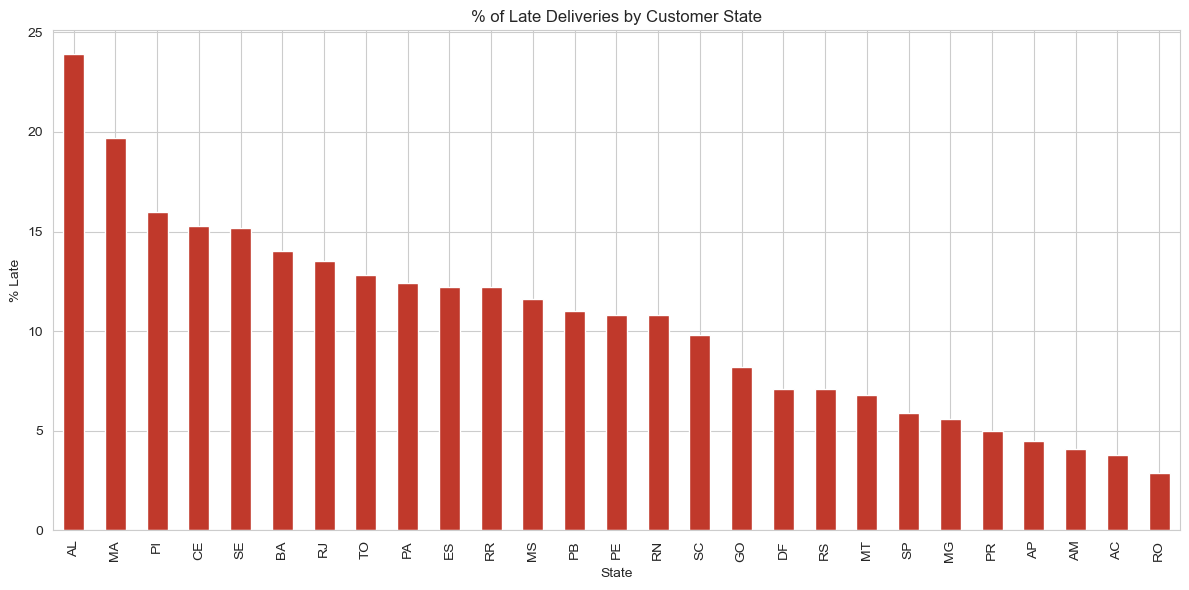

In [76]:
plt.figure(figsize=(12,6))
state_late_pct.plot(kind="bar", color="#c0392b")
plt.title("% of Late Deliveries by Customer State")
plt.ylabel("% Late")
plt.xlabel("State")
plt.tight_layout()
plt.savefig("state_late_pct.png", dpi=150)
plt.show()

3.4 explanation: This just pulls out the 10 worst states on their own, sorted from worst to least-worst. This is the exact list you'll point to when you tell the CEO "focus your repair efforts here first" — it's the direct answer to the Regional Director's user story.

In [77]:
state_late_pct.head(10)

customer_state
AL    23.9
MA    19.7
PI    16.0
CE    15.3
SE    15.2
BA    14.0
RJ    13.5
TO    12.8
PA    12.4
ES    12.2
Name: is_late, dtype: float64

**Interpretation:** The late-delivery problem is clearly **regional, not
nationwide**. São Paulo (SP) — home to Olist's main distribution hub — has one
of the lowest late-delivery rates in the country at 5.9%. By contrast, the
worst-performing states are concentrated in Brazil's Northeast: Alagoas (23.9%),
Maranhão (19.7%), Piauí (16.0%), Ceará (15.3%), and Sergipe (15.2%) — all far
from the hub. This strongly suggests distance from the distribution center is
the primary driver of late deliveries. One notable exception is Rio de Janeiro
(13.5%), which is geographically close to São Paulo but still underperforms —
worth a separate investigation, since it can't be explained by distance alone.

## Story 4 — The Sentiment Correlation

**Goal:** Prove (or disprove) that late deliveries are actually causing bad
reviews — not just assumed to. This is what the CEO needs to justify treating
logistics as the priority fix.

**Approach:** Compare average review scores across delivery statuses, then
look at the relationship more closely — does the review score keep dropping
the *later* an order is, or is there a flat cliff at "late vs not late"?

4.1 EXPLANATION: Same grouping technique as Story 3, but this time we're averaging the review score (1 to 5 stars) instead of a Yes/No column. This gives one simple number per delivery status — "orders that were On Time averaged X stars, Late orders averaged Y stars" — which is the clearest possible way to show whether lateness hurts satisfaction.

In [78]:
avg_score_by_status = delivered.groupby("Delivery_Status")["review_score"].mean().round(2)
avg_score_by_status

Delivery_Status
Late          3.46
On Time       4.29
Super Late    1.78
Name: review_score, dtype: float64

4.2 EXPLANATION: This draws the numbers from the last cell as a simple bar chart, with green for On Time, orange for Late, and red for Super Late — using color intuitively so anyone looking at it instantly reads "green is good, red is bad" without needing the legend explained to them. Fixing the y-axis from 0 to 5 (plt.ylim(0,5)) matters here: it stops small differences from looking artificially dramatic, and shows the true scale of the drop

C:\Users\PC\AppData\Local\Temp\ipykernel_2788\2416968334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_score_by_status.index, y=avg_score_by_status.values,


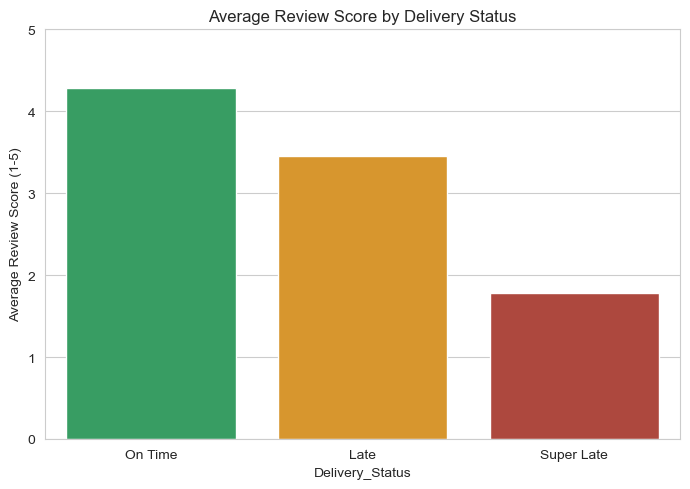

In [79]:
plt.figure(figsize=(7,5))
sns.barplot(x=avg_score_by_status.index, y=avg_score_by_status.values,
            order=["On Time","Late","Super Late"],
            palette=["#27ae60","#f39c12","#c0392b"])
plt.title("Average Review Score by Delivery Status")
plt.ylabel("Average Review Score (1-5)")
plt.ylim(0,5)
plt.tight_layout()
plt.savefig("score_by_status.png", dpi=150)
plt.show()

4.3 EXPLANATION:This goes one level deeper than the last chart. Instead of just three buckets (On Time / Late / Super Late), we're grouping orders into finer bands of how many days late they were — 1-3 days, 4-7 days, and so on — and checking the average review score at each band. delay_days_late first converts our delay number into "how many days late, or 0 if not late" (the .clip(lower=0) turns any early delivery into 0 instead of a negative number, since we only care about lateness here). This tells us whether score keeps dropping steadily the later a package is, or whether it flattens out.

In [80]:
delivered["delay_days_late"] = (-delivered["Days_Difference"]).clip(lower=0)

bins = [-1, 0, 3, 7, 14, 30, 1000]
labels = ["0 (on time)", "1-3", "4-7", "8-14", "15-30", "30+"]
delivered["delay_bucket"] = pd.cut(delivered["delay_days_late"], bins=bins, labels=labels)

bucket_scores = delivered.groupby("delay_bucket", observed=True)["review_score"].mean()
bucket_scores

delay_bucket
0 (on time)    4.294001
1-3            3.765933
4-7            2.318105
8-14           1.743135
15-30          1.614126
30+            2.026239
Name: review_score, dtype: float64

4.4 EXPLANATION: A line chart is the right shape here (rather than bars) because we're showing a trend across an increasing scale — "as delay grows, what happens to the score?" The dots (marker="o") mark the actual average at each delay band, connected by a line so the trend is visually obvious at a glance.

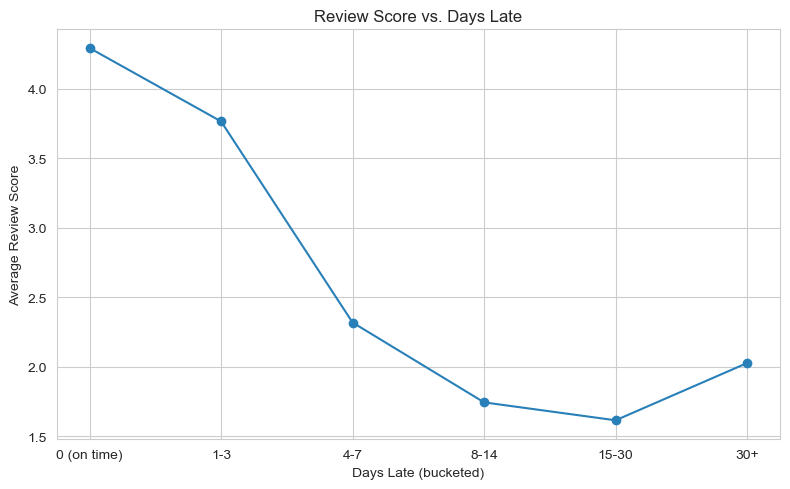

In [81]:
plt.figure(figsize=(8,5))
bucket_scores.plot(kind="line", marker="o", color="#2980b9")
plt.title("Review Score vs. Days Late")
plt.xlabel("Days Late (bucketed)")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.savefig("score_vs_delay_days.png", dpi=150)
plt.show()

4.5 EXPLANATION: This calculates one single number — a correlation — that summarizes the whole relationship between "how late was it" and "how many stars did they give." It ranges from -1 to +1. A number close to 0 means no relationship. A negative number means: as delay goes up, review score goes down — which is exactly what we'd expect to see if the CEO's gut feeling is correct. The closer to -1, the stronger that relationship is.
Run cells 16–20 and send me the outputs — especially that correlation number at the end. That's the single statistic that either proves or disproves the CEO's whole hypothesis, so it matters more than almost anything else in this notebook.

In [82]:
corr = delivered[["delay_days_late","review_score"]].corr().iloc[0,1]
print(f"Correlation between days late and review score: {corr:.3f}")

Correlation between days late and review score: -0.276


**Interpretation:** Late deliveries clearly hurt customer sentiment. Average
review scores fall from 4.29 stars (On Time) to 3.46 (Late) to just 1.78
(Super Late) — a drop of over 2.5 stars for our worst-performing deliveries.
The correlation between days late and review score is -0.276: a real, moderate
negative relationship, confirming that lateness drives dissatisfaction, though
it isn't the only factor (other elements like product quality likely also
influence scores). Interestingly, the decline isn't perfectly linear — scores
dip most sharply between 4 and 30 days late, but tick slightly upward again
for orders over 30 days late, possibly due to compensation/refunds softening
the experience for the most extreme delays, or a smaller sample size in that
bucket. This is strong evidence for the CEO: logistics performance is directly
costing Veridi customer satisfaction, and the Northeast states identified in
Story 3 are the highest-leverage place to fix it.

## Bonus — Product Category Translation

**Goal:** `product_category_name` is in Portuguese (e.g. `cama_mesa_banho`).
Translate it into English so the dashboard is understandable to a global
audience, and check whether certain product categories are more prone to
late delivery than others.

**Step 1:** Bring in product and order-item data, since category lives on the
product table, not the order table.

5.1 EXPLANATION: Category information isn't stored on the orders table directly — it lives on the products table, and the link between an order and its products is this separate order_items file. So before we can attach a category to each order, we need to load this file first.

In [83]:
order_items = pd.read_csv("Dataset/olist_order_items_dataset.csv")
order_items.shape

(112650, 7)

5.2 EXPLANATION: Here's a subtlety: one order can contain multiple products (someone buys a lamp and a rug in the same order). Since our master table has one row per order, we can't attach every product's category to it without duplicating rows again — the same trap as Story 1. So we make a judgment call: represent each order by its highest-value item (sort_values("price", ascending=False) then keep the first row per order). This is a reasonable simplification worth stating out loud in your README — it's an assumption, not a hidden trick.

In [84]:
order_items_primary = (order_items.sort_values("price", ascending=False)
                        .drop_duplicates(subset="order_id", keep="first"))

order_items_primary.shape

(98666, 7)

5.3 EXPLANATION: Two merges here. The first attaches the product's details (including its Portuguese category name) using the shared product_id. The second uses the translation file to look up the English version of that category name. After this, every order-item row carries both the original Portuguese label and its English translation side by side.

In [85]:
order_items_primary = order_items_primary.merge(products, on="product_id", how="left")
order_items_primary = order_items_primary.merge(translation, on="product_category_name", how="left")

order_items_primary[["order_id", "product_category_name", "product_category_name_english"]].head(5)

,order_id,product_category_name,product_category_name_english
0,0812eb902a67711a1cb742b3cdaa65ae,utilidades_domesticas,housewares
1,fefacc66af859508bf1a7934eab1e97f,pcs,computers
2,f5136e38d1a14a4dbd87dff67da82701,artes,art
3,a96610ab360d42a2e5335a3998b4718a,eletroportateis,small_appliances
4,199af31afc78c699f0dbf71fb178d4d4,eletroportateis,small_appliances


5.4 EXPLANATION: Finally, we attach the English category name onto our main delivered table using order_id as the shared key. We also print how many orders ended up with no category at all — a small number here is normal and expected (some orders just don't have a clean product match), but a large number would be a red flag worth investigating.

In [86]:
delivered = delivered.merge(
    order_items_primary[["order_id", "product_category_name_english"]],
    on="order_id", how="left"
)

print("Orders missing a category:", delivered["product_category_name_english"].isna().sum())
delivered.head(3)

Orders missing a category: 1379


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_delivered,Days_Difference,Delivery_Status,is_late,delay_days_late,delay_bucket,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,True,7.0,On Time,False,0.0,0 (on time),housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,True,5.0,On Time,False,0.0,0 (on time),perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,True,17.0,On Time,False,0.0,0 (on time),auto


5.5 EXPLAMATION: Same late-percentage logic as Story 3, but grouped by category instead of state. The .query("count >= 100") line filters out tiny categories with only a handful of orders — a category with 3 orders and 1 late delivery would show "33% late," which is a misleading statistic based on almost no data. Requiring at least 100 orders keeps the comparison fair.
Run cells 21–25 and send me the top 10 categories. Once I see that, I'll walk you through the Candidate's Choice section — the seller-vs-carrier delay attribution — which is the piece that'll really make your submission stand out.

In [87]:
category_late_pct = (delivered.groupby("product_category_name_english")["is_late"]
                      .agg(["mean", "count"])
                      .query("count >= 100")
                      .sort_values("mean", ascending=False))

category_late_pct["mean"] = (category_late_pct["mean"] * 100).round(1)
category_late_pct.head(10)

,mean,count
product_category_name_english,,
audio,13.1,344
fashion_underwear_beach,12.8,117
books_technical,11.0,254
home_confort,10.8,371
food,10.1,436
electronics,9.9,2502
christmas_supplies,9.7,124
baby,9.3,2760
construction_tools_construction,9.3,724


**Interpretation:** Category has a much weaker relationship with delay than
geography does. The worst-performing categories — audio (13.1% late),
fashion/underwear/beach (12.8%), and technical books (11.0%) — don't share an
obvious pattern like "bulky" or "fragile" items. This suggests product type is
a minor factor at most; the dominant driver of Veridi's delivery problem is
still where the customer is located (Story 3), not what they bought.

## Candidate's Choice — Delay Attribution: Seller Processing vs. Carrier Transit

**Business justification:** So far, we know *that* Veridi is late and *where*
it's worst. But "we're late" isn't something the CEO can act on directly —
she needs to know **who to fix**. A late order could be late for two very
different reasons:

1. **The seller was slow to hand the package to the carrier** (a seller
   management / SLA problem)
2. **The carrier took too long once they had the package** (a shipping /
   logistics partner problem)

These require completely different fixes with different owners and different
costs — enforcing stricter processing-time SLAs on sellers vs. renegotiating
carrier contracts or routes. This analysis splits total delivery time into
these two stages using timestamps that already exist in our data, so we can
tell the CEO exactly where the time is being lost.

6.1 EXPLANATION: We're breaking one big time gap into two smaller, more useful ones. seller_processing_days measures how long the seller took to hand the package to the carrier after the order was approved — the seller's responsibility. carrier_transit_days measures how long the carrier took to actually deliver it once they had it — the carrier's responsibility. Both use dates we already have; we're just subtracting different pairs of columns than before.

In [88]:
delivered["seller_processing_days"] = (delivered["order_delivered_carrier_date"] -
                                        delivered["order_approved_at"]).dt.days
delivered["carrier_transit_days"] = (delivered["order_delivered_customer_date"] -
                                      delivered["order_delivered_carrier_date"]).dt.days

delivered[["order_id", "seller_processing_days", "carrier_transit_days"]].head(5)

,order_id,seller_processing_days,carrier_transit_days
0,e481f51cbdc54678b7cc49136f2d6af7,2.0,6.0
1,53cdb2fc8bc7dce0b6741e2150273451,0.0,12.0
2,47770eb9100c2d0c44946d9cf07ec65d,0.0,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,3.0,9.0
4,ad21c59c0840e6cb83a9ceb5573f8159,0.0,1.0


6.2 EXPLANATION:  This time we filter down to only the late orders (delivered["is_late"]) — we don't care how fast on-time orders moved, we care what's slowing down the late ones specifically. Then we average both new columns to get: "on average, a late order spends X days with the seller and Y days with the carrier."

In [89]:
attribution = delivered[delivered["is_late"]][["seller_processing_days","carrier_transit_days"]].mean().round(2)
attribution

seller_processing_days     4.82
carrier_transit_days      25.19
dtype: float64

6.3 EXPLANATION: This converts those two average day-counts into percentages that add up to 100% — e.g. "60% of a late order's total time is spent with the carrier, 40% with the seller." A percentage split is easier for a non-technical audience to act on than raw day counts, and it directly tells the CEO where to focus: whichever side has the bigger share is the bigger lever to pull.

In [90]:
share = attribution / attribution.sum() * 100
share.round(1)

seller_processing_days    16.1
carrier_transit_days      83.9
dtype: float64

6.4 EXPLANATION: A pie chart works well here specifically because we have exactly two categories that add up to a whole (100%) — it makes "which side is bigger" visually obvious in a single glance, which is ideal for a slide you'll only have 10 seconds to explain in a presentation.

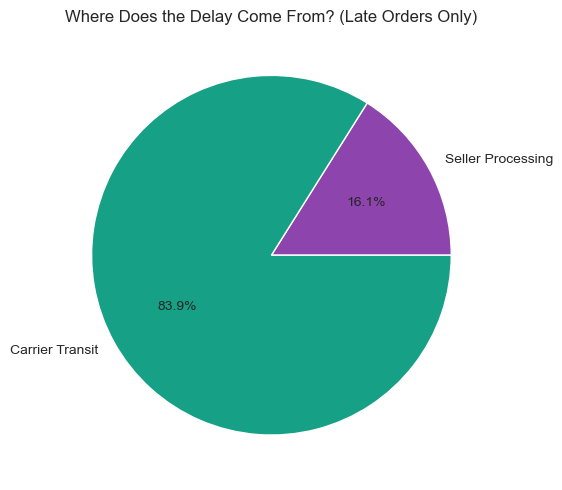

In [91]:
plt.figure(figsize=(6,5))
share.plot(kind="pie", autopct="%1.1f%%",
           labels=["Seller Processing","Carrier Transit"],
           colors=["#8e44ad","#16a085"])
plt.ylabel("")
plt.title("Where Does the Delay Come From? (Late Orders Only)")
plt.tight_layout()
plt.savefig("delay_attribution.png", dpi=150)
plt.show()

**Interpretation:** The delay is overwhelmingly a **carrier/logistics problem,
not a seller problem**. Among late orders, sellers only account for 16.1% of
the excess time (4.8 days on average) before handing off to the carrier, while
83.9% of the delay (25.2 days on average) happens during carrier transit. This
aligns directly with the geographic findings in Story 3 — the worst-performing
states are the ones farthest from the distribution hub, which is exactly what
you'd expect if carrier transit time is the bottleneck. **Recommendation:**
Veridi should prioritize renegotiating carrier logistics/routes for the
Northeast region over placing pressure on sellers, since sellers are not the
primary source of the delay.

In [92]:
dashboard_cols = ["order_id", "customer_state", "review_score", "Delivery_Status",
                   "Days_Difference", "product_category_name_english", "delay_days_late"]

dashboard_export = delivered[dashboard_cols].copy()
dashboard_export.to_csv("veridi_processed.csv", index=False)

print("Saved veridi_processed.csv:", dashboard_export.shape)

Saved veridi_processed.csv: (96470, 7)


This pulls out only the columns the dashboard actually needs (no review text, no raw dates, no ID columns you won't chart) and saves them as a new, much smaller CSV. This is the file — not the original massive Olist CSVs — that you'll commit to GitHub and connect to Streamlit.

#### Export a separate file just for the delay attribution pie chart

In [93]:
pie_data = delivered.loc[
    delivered["is_late"],
    ["order_id", "seller_processing_days", "carrier_transit_days"]
].melt(
    id_vars="order_id",
    value_vars=["seller_processing_days", "carrier_transit_days"],
    var_name="Delay_Stage",
    value_name="Delay_Days"
)

pie_data["Delay_Stage"] = pie_data["Delay_Stage"].map({
    "seller_processing_days": "Seller Processing",
    "carrier_transit_days": "Carrier Transit"
})

pie_data.to_csv("delay_attribution.csv", index=False)
print("Saved delay_attribution.csv:", pie_data.shape)
pie_data.head(6)

Saved delay_attribution.csv: (15652, 3)


,order_id,Delay_Stage,Delay_Days
0,203096f03d82e0dffbc41ebc2e2bcfb7,Seller Processing,17.0
1,fbf9ac61453ac646ce8ad9783d7d0af6,Seller Processing,4.0
2,8563039e855156e48fccee4d611a3196,Seller Processing,3.0
3,6ea2f835b4556291ffdc53fa0b3b95e8,Seller Processing,18.0
4,66e4624ae69e7dc89bd50222b59f581f,Seller Processing,5.0
5,a685d016c8a26f71a0bb67821070e398,Seller Processing,8.0
